                            Stroke Prediction - Project

                            Setup & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [ ]:

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


        id  gender   age  hypertension  heart_disease ever_married      work_type Residence_type  avg_glucose_level   bmi   smoking_status  stroke
0     9046    Male  67.0             0              1          Yes        Private          Urban             228.69  36.6  formerly smoked       1
1    51676  Female  61.0             0              0          Yes  Self-employed          Rural             202.21   NaN     never smoked       1
2    31112    Male  80.0             0              1          Yes        Private          Rural             105.92  32.5     never smoked       1
3    60182  Female  49.0             0              0          Yes        Private          Urban             171.23  34.4           smokes       1
4     1665  Female  79.0             1              0          Yes  Self-employed          Rural             174.12  24.0     never smoked       1

                              EDA (Exploratory Data Analysis)


In [3]:
df.info()
print("\n--- Numeric summary ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5110 non-null   int64  
 1   gender              5110 non-null   object 
 2   age                 5110 non-null   float64
 3   hypertension        5110 non-null   int64  
 4   heart_disease       5110 non-null   int64  
 5   ever_married        5110 non-null   object 
 6   work_type           5110 non-null   object 
 7   Residence_type      5110 non-null   object 
 8   avg_glucose_level   5110 non-null   float64
 9   bmi                 4909 non-null   float64
 10  smoking_status      5110 non-null   object 
 11  stroke              5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

--- Numeric summary ---


                 id          age  hypertension  heart_disease  avg_glucose_level          bmi       stroke
count  5110.000000  5110.000000   5110.000000    5110.000000       5110.000000  4909.000000  5110.000000
mean  36517.829354    43.226614      0.097456       0.053915        106.147677    28.893237     0.048728
std   21161.721625    22.612647      0.296607       0.225930         45.283560     7.854067     0.215320
min      67.000000     0.080000      0.000000       0.000000         55.120000    10.300000     0.000000
25%   17741.250000    25.000000      0.000000       0.000000         77.245000    23.500000     0.000000
50%   36932.000000    45.000000      0.000000       0.000000         91.885000    28.100000     0.000000
75%   54682.000000    61.000000      0.000000       0.000000        114.090000    33.100000     0.000000
max   72940.000000    82.000000      1.000000       1.000000        271.740000    97.600000     1.000000

In [ ]:

print("Missing values:\n", df.isnull().sum())
print("\nMissing % :\n", (df.isnull().mean()*100).round(2))

Missing values:
 id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status          0
stroke                  0
dtype: int64

Missing % :
 id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64


0    4861
1     249
Name: stroke, dtype: int64

Stroke rate: 4.87 %


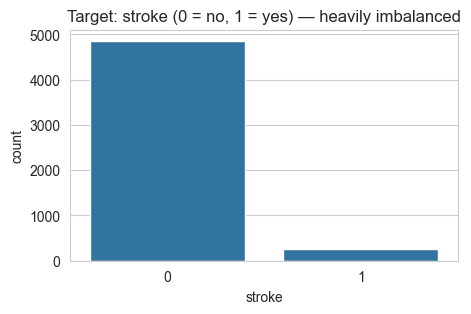

In [ ]:

print(df['stroke'].value_counts())
print("\nStroke rate:", round(df['stroke'].mean()*100, 2), "%")

plt.figure(figsize=(5,3))
sns.countplot(x='stroke', data=df)
plt.title("Target: stroke (0 = no, 1 = yes) â€” heavily imbalanced")
plt.show()

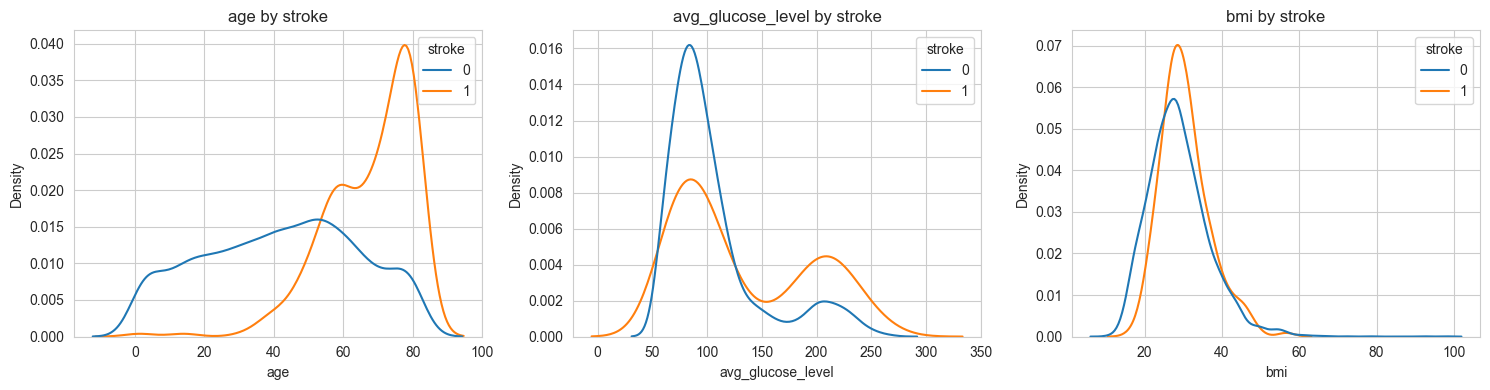

In [ ]:

num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, ax = plt.subplots(1, 3, figsize=(15,4))
for i, c in enumerate(num_cols):
    sns.kdeplot(data=df, x=c, hue='stroke', common_norm=False, ax=ax[i])
    ax[i].set_title(f"{c} by stroke")
plt.tight_layout(); plt.show()

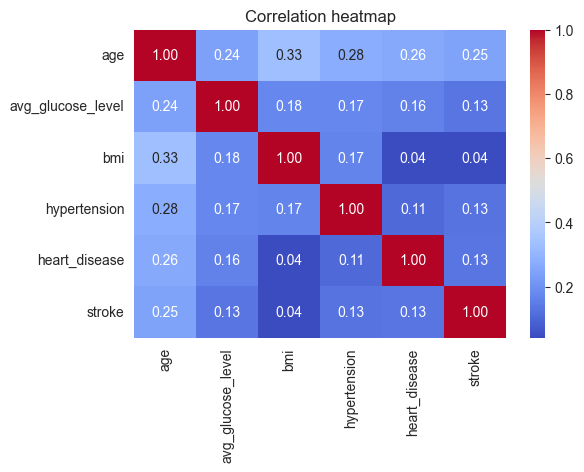

In [ ]:

plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols + ['hypertension','heart_disease','stroke']].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap"); plt.show()

In [8]:
# Categorical vs target (quick look)
cat_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']
for c in cat_cols:
    print(f"\n{c} -> stroke rate:")
    print((df.groupby(c)['stroke'].mean()*100).round(2))


gender -> stroke rate:
gender
Female    4.74
Male      5.09
Other     0.00
Name: stroke, dtype: float64

ever_married -> stroke rate:
ever_married
No     1.50
Yes    6.76
Name: stroke, dtype: float64

work_type -> stroke rate:
work_type
Govt_job        5.32
Never_worked    0.00
Private         4.65
Self-employed   7.88
children        0.61
Name: stroke, dtype: float64

Residence_type -> stroke rate:
Residence_type
Rural    4.96
Urban    4.78
Name: stroke, dtype: float64

smoking_status -> stroke rate:
smoking_status
Unknown            3.53
formerly smoked    7.87
never smoked       3.85
smokes             5.34
Name: stroke, dtype: float64


                                ETL

In [9]:
df = df.drop(columns=['id'])

# (optional) 'Other' gender ka sirf 1 row hota hai
print("Gender counts:\n", df['gender'].value_counts())
print("\nClean shape:", df.shape)

Gender counts:
 Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

Clean shape: (5110, 11)


                                Feature Engineering & Preprocessing

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender','ever_married','work_type','Residence_type','smoking_status']
binary_features = ['hypertension','heart_disease']

numeric_tf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_tf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_tf, numeric_features),
    ('cat', categorical_tf, categorical_features),
    ('bin', 'passthrough', binary_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'ever_married', 'work_type',
                                  'Residence_type', 'smoking_status']),
                                ('bin', 'passthrough',
                                 ['hypertension', 'heart_disease'])])

                                           Linear Regression 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# bmi ke known rows hi regression ke liye (NaN target nahi chahiye)
reg_df = df[df['bmi'].notna()].copy()
reg_features = ['age','avg_glucose_level','gender','ever_married','work_type',
                'Residence_type','smoking_status','hypertension','heart_disease']
Xr = reg_df[reg_features]
yr = reg_df['bmi']

# bmi ko features se hata diya, isliye chhota preprocessor banate hain
reg_pre = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),
     ['age','avg_glucose_level']),
    ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                      ('ohe',OneHotEncoder(handle_unknown='ignore'))]),
     ['gender','ever_married','work_type','Residence_type','smoking_status']),
    ('bin','passthrough',['hypertension','heart_disease'])
])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)
lin = Pipeline([('pre', reg_pre), ('model', LinearRegression())])
lin.fit(Xr_tr, yr_tr)
pred = lin.predict(Xr_te)

print("R2  :", round(r2_score(yr_te, pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_te, pred)), 3))
# Note: R2 modest aayega â€” yeh realistic hai, concept samajhne ke liye theek.

R2  : 0.027
RMSE: 7.854


                      Classification Setup (Stratified Split)

In [12]:
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train stroke rate:", round(y_train.mean()*100,2), "%")
print("Test  stroke rate:", round(y_test.mean()*100,2), "%")

Train: (4088, 10)  Test: (1022, 10)
Train stroke rate: 4.87 %
Test  stroke rate: 4.89 %


                                 Baseline Models + Evaluation


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

def evaluate(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    # ROC-AUC ke liye probability
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_te)[:,1]
    else:
        y_score = pipe.decision_function(X_te)
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(y_te, y_pred), 3),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_te, y_pred), 3),
        "F1":        round(f1_score(y_te, y_pred), 3),
        "ROC_AUC":   round(roc_auc_score(y_te, y_score), 3),
    }

def make_pipe(clf):
    return Pipeline([('pre', preprocessor), ('clf', clf)])

In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN":               KNeighborsClassifier(),
    "NaiveBayes":        GaussianNB(),
    "DecisionTree":      DecisionTreeClassifier(random_state=42),
    "RandomForest":      RandomForestClassifier(random_state=42),
    "SVM":               SVC(probability=True, random_state=42),
}

results = []
for name, clf in models.items():
    pipe = make_pipe(clf)
    pipe.fit(X_train, y_train)
    results.append(evaluate(name, pipe, X_test, y_test))

baseline = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
baseline

                Model  Accuracy  Precision  Recall    F1  ROC_AUC
0          NaiveBayes     0.820      0.134   0.460  0.207    0.830
1        DecisionTree     0.929      0.130   0.120  0.125    0.558
2                 KNN     0.948      0.200   0.020  0.036    0.690
3        RandomForest     0.951      0.500   0.020  0.038    0.840
4  LogisticRegression     0.950      0.000   0.000  0.000    0.840
5                 SVM     0.951      0.000   0.000  0.000    0.836

                                    Class Imbalance Handling


In [15]:
bal_models = {
    "LogReg_bal": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "DT_bal":     DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "RF_bal":     RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM_bal":    SVC(probability=True, random_state=42, class_weight='balanced'),
}

bal_results = []
for name, clf in bal_models.items():
    pipe = make_pipe(clf)
    pipe.fit(X_train, y_train)
    bal_results.append(evaluate(name, pipe, X_test, y_test))

pd.DataFrame(bal_results).sort_values("Recall", ascending=False).reset_index(drop=True)
# Recall ab kaafi badhega (Accuracy thoda girega) â€” yahi trade-off hai.

        Model  Accuracy  Precision  Recall    F1  ROC_AUC
0  LogReg_bal     0.760      0.150   0.740  0.247    0.840
1     SVM_bal     0.740      0.138   0.740  0.232    0.842
2      DT_bal     0.800      0.148   0.560  0.234    0.687
3      RF_bal     0.900      0.230   0.380  0.287    0.858

                                  Model Tuning (GridSearchCV)


In [16]:
from sklearn.model_selection import GridSearchCV

rf_pipe = make_pipe(RandomForestClassifier(random_state=42, class_weight='balanced'))
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}
grid = GridSearchCV(rf_pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 3))
best_rf = grid.best_estimator_
evaluate("RF_tuned", best_rf, X_test, y_test)

Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1 : 0.281


{'Model': 'RF_tuned', 'Accuracy': 0.89, 'Precision': 0.22, 'Recall': 0.4, 'F1': 0.285, 'ROC_AUC': 0.862}

                                         Ensemble Learning


In [17]:
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)

ens_results = []

# 1) Bagging
bag = make_pipe(BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
        n_estimators=100, random_state=42))
bag.fit(X_train, y_train)
ens_results.append(evaluate("Bagging", bag, X_test, y_test))

# 2) Boosting - AdaBoost
ada = make_pipe(AdaBoostClassifier(n_estimators=200, random_state=42))
ada.fit(X_train, y_train)
ens_results.append(evaluate("AdaBoost", ada, X_test, y_test))

# 2b) Boosting - GradientBoosting
gb = make_pipe(GradientBoostingClassifier(random_state=42))
gb.fit(X_train, y_train)
ens_results.append(evaluate("GradientBoosting", gb, X_test, y_test))

# 3) Stacking - KNN + SVM + DT  ->  meta: LogisticRegression
stack = make_pipe(StackingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
        ('dt',  DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5))
stack.fit(X_train, y_train)
ens_results.append(evaluate("Stacking", stack, X_test, y_test))

pd.DataFrame(ens_results).sort_values("F1", ascending=False).reset_index(drop=True)

              Model  Accuracy  Precision  Recall    F1  ROC_AUC
0          Stacking     0.780      0.160   0.700  0.260    0.850
1           Bagging     0.880      0.210   0.420  0.280    0.840
2          AdaBoost     0.940      0.280   0.140  0.187    0.850
3  GradientBoosting     0.951      0.500   0.040  0.074    0.863

                                Final Comparison + Best Model Analysis


In [18]:
all_results = pd.DataFrame(results + bal_results + ens_results +
                          [evaluate("RF_tuned", best_rf, X_test, y_test)])
all_results = all_results.sort_values("F1", ascending=False).reset_index(drop=True)
all_results

                Model  Accuracy  Precision  Recall    F1  ROC_AUC
0              RF_bal     0.900      0.230   0.380  0.287    0.858
1            RF_tuned     0.890      0.220   0.400  0.285    0.862
2             Bagging     0.880      0.210   0.420  0.280    0.840
3            Stacking     0.780      0.160   0.700  0.260    0.850
4          LogReg_bal     0.760      0.150   0.740  0.247    0.840
5              DT_bal     0.800      0.148   0.560  0.234    0.687
6             SVM_bal     0.740      0.138   0.740  0.232    0.842
7          NaiveBayes     0.820      0.134   0.460  0.207    0.830
8            AdaBoost     0.940      0.280   0.140  0.187    0.850
9        DecisionTree     0.929      0.130   0.120  0.125    0.558
10   GradientBoosting     0.951      0.500   0.040  0.074    0.863
11       RandomForest     0.951      0.500   0.020  0.038    0.840
12                KNN     0.948      0.200   0.020  0.036    0.690
13 LogisticRegression     0.950      0.000   0.000  0.000    0.

Best by F1: RF_bal
              precision    recall  f1-score   support

           0      0.983     0.894     0.936       972
           1      0.220     0.520     0.309        50

    accuracy                          0.880      1022
   macro avg      0.602     0.707     0.622      1022
weighted avg      0.941     0.880     0.907      1022



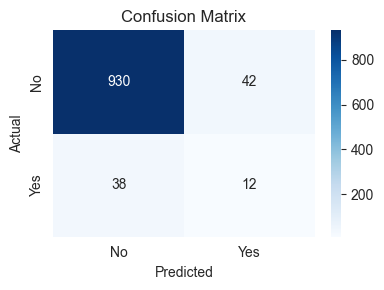

In [ ]:

best_name = all_results.iloc[0]['Model']
print("Best by F1:", best_name)


final_model = best_rf
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

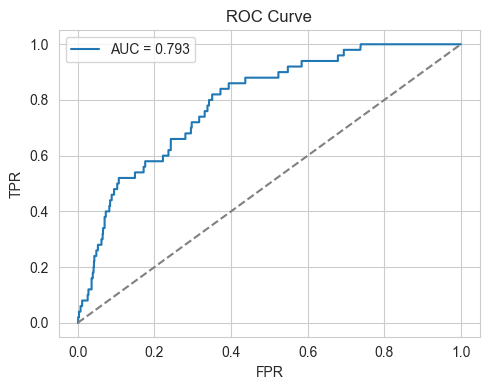

In [20]:
# ROC curve
y_score = final_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score):.3f}")
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()
plt.show()